**Question 9**

In [13]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv


In [14]:
brent_df = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv")
gold_df = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv")
silver_df = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv")


In [15]:
print("Brent columns:", brent_df.columns)
print("Gold columns:", gold_df.columns)
print("Silver columns:", silver_df.columns)


Brent columns: Index(['Date', 'Value'], dtype='object')
Gold columns: Index(['Date', 'Value'], dtype='object')
Silver columns: Index(['Date', 'Value'], dtype='object')


,Year,Average_Brent_Oil_Price
0,1946,22.898333
1,1947,27.201667
2,1948,35.307500
3,1949,35.647500
4,1950,35.277500
...,...,...
76,2022,106.452500
77,2023,84.192500
78,2024,79.832500
79,2025,65.926667


,Year,Average_Gold_Price
0,1915,19.250000
1,1916,19.470000
2,1917,19.660000
3,1918,19.840000
4,1919,20.030000
...,...,...
107,2022,1798.956575
108,2023,1953.688517
109,2024,2404.577567
110,2025,3472.540975


,Year,Average_Silver_Price
0,1915,0.510000
1,1916,0.670000
2,1917,0.840000
3,1918,0.980000
4,1919,1.130000
...,...,...
107,2022,21.671767
108,2023,23.579675
109,2024,28.128033
110,2025,41.501500


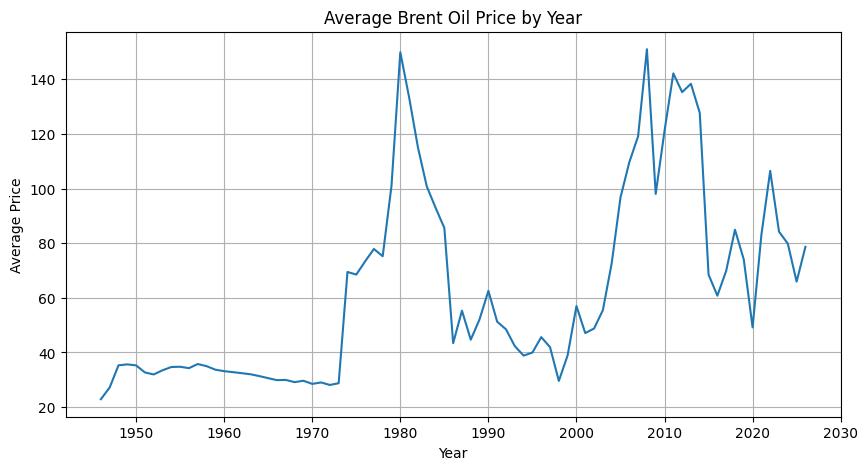

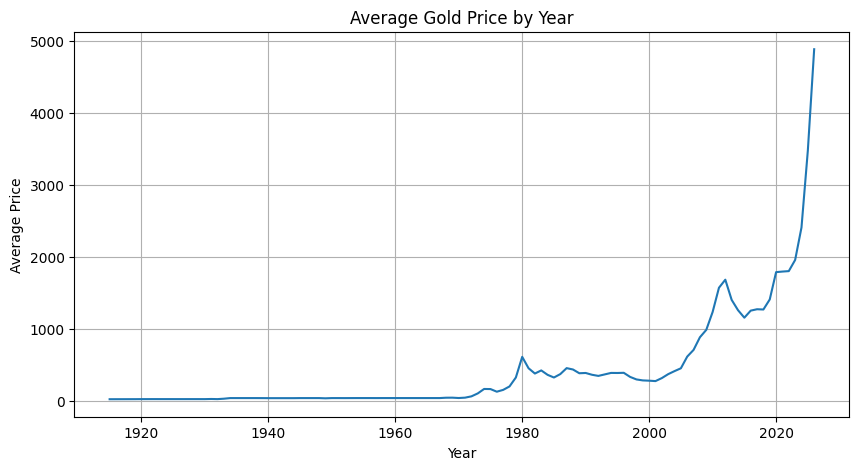

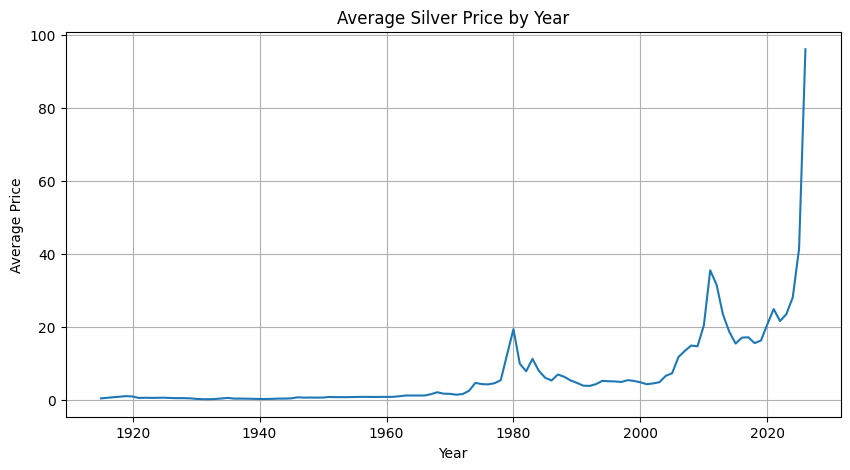

CSV files and PDF graphs saved successfully


In [19]:
# Convert Date column
brent_df["Date"] = pd.to_datetime(brent_df["Date"], errors="coerce")
gold_df["Date"] = pd.to_datetime(gold_df["Date"], errors="coerce")
silver_df["Date"] = pd.to_datetime(silver_df["Date"], errors="coerce")

# Create Year column
brent_df["Year"] = brent_df["Date"].dt.year
gold_df["Year"] = gold_df["Date"].dt.year
silver_df["Year"] = silver_df["Date"].dt.year

# Calculate yearly average prices
brent_avg = brent_df.groupby("Year")["Value"].mean().reset_index()
gold_avg = gold_df.groupby("Year")["Value"].mean().reset_index()
silver_avg = silver_df.groupby("Year")["Value"].mean().reset_index()

# Rename columns
brent_avg.columns = ["Year", "Average_Brent_Oil_Price"]
gold_avg.columns = ["Year", "Average_Gold_Price"]
silver_avg.columns = ["Year", "Average_Silver_Price"]

# Display tables
display(brent_avg)
display(gold_avg)
display(silver_avg)

# Save tables as CSV
brent_avg.to_csv("average_brent_oil_price_by_year.csv", index=False)
gold_avg.to_csv("average_gold_price_by_year.csv", index=False)
silver_avg.to_csv("average_silver_price_by_year.csv", index=False)

# Brent Oil Graph
plt.figure(figsize=(10,5))
plt.plot(brent_avg["Year"], brent_avg["Average_Brent_Oil_Price"])
plt.title("Average Brent Oil Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.grid(True)
plt.savefig("average_brent_oil_price_by_year.pdf")
plt.show()

# Gold Graph
plt.figure(figsize=(10,5))
plt.plot(gold_avg["Year"], gold_avg["Average_Gold_Price"])
plt.title("Average Gold Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.grid(True)
plt.savefig("average_gold_price_by_year.pdf")
plt.show()

# Silver Graph
plt.figure(figsize=(10,5))
plt.plot(silver_avg["Year"], silver_avg["Average_Silver_Price"])
plt.title("Average Silver Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.grid(True)
plt.savefig("average_silver_price_by_year.pdf")
plt.show()

print("CSV files and PDF graphs saved successfully")